# Exploración del dataset DeepPCB

Análisis exploratorio del dataset DeepPCB utilizado para la detección automática de defectos en PCBs.

## Objetivos

- Comprender la estructura del dataset.
- Analizar la partición original de entrenamiento y prueba.
- Verificar la correspondencia entre imágenes y anotaciones.
- Analizar la distribución de las clases de defectos.
- Analizar el tamaño y las características de las *bounding boxes*.
- Visualizar muestras representativas con sus anotaciones.
- Identificar posibles problemas antes de convertir el dataset al formato requerido por YOLO.

In [1]:
from pathlib import Path
from collections import Counter

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. Configuración de rutas

Se definen las rutas principales del proyecto utilizando rutas relativas. Esto permite mantener la reproducibilidad del análisis independientemente de la ubicación local del repositorio.

In [2]:
# Detectar la raíz del proyecto
PROJECT_ROOT = Path.cwd().parent

# Definir rutas principales
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DEEPPCB_DIR = DATA_RAW_DIR / "DeepPCB-master"
PCB_DATA_DIR = DEEPPCB_DIR / "PCBData"

TRAINVAL_FILE = PCB_DATA_DIR / "trainval.txt"
TEST_FILE = PCB_DATA_DIR / "test.txt"

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Dataset DeepPCB: {DEEPPCB_DIR}")
print(f"PCBData: {PCB_DATA_DIR}")

Raíz del proyecto: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo
Dataset DeepPCB: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master
PCBData: c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master\PCBData


In [ ]:
# Verificar que las rutas existan
assert PROJECT_ROOT.exists(), "No se encontró la raíz del proyecto."
assert DEEPPCB_DIR.exists(), "No se encontró el dataset DeepPCB."
assert PCB_DATA_DIR.exists(), "No se encontró la carpeta PCBData."
assert TRAINVAL_FILE.exists(), "No se encontró trainval.txt."
assert TEST_FILE.exists(), "No se encontró test.txt."

print("Todas las rutas fueron validadas correctamente.")

Todas las rutas fueron validadas correctamente.


## 2. Análisis de las particiones originales

DeepPCB proporciona archivos que definen una partición original de los datos. Antes de preparar el dataset para YOLO, se analiza su contenido con el objetivo de comprender cómo se identifican las muestras y cuántas observaciones pertenecen a cada conjunto.

Se utilizarán los archivos `trainval.txt` y `test.txt`, preservando inicialmente la separación de prueba propuesta por los autores del dataset.

In [4]:
# Leer las particiones originales
with open(TRAINVAL_FILE, "r", encoding="utf-8") as file:
    trainval_samples = [
        line.strip()
        for line in file
        if line.strip()
    ]

with open(TEST_FILE, "r", encoding="utf-8") as file:
    test_samples = [
        line.strip()
        for line in file
        if line.strip()
    ]

print(f"Muestras en trainval: {len(trainval_samples)}")
print(f"Muestras en test: {len(test_samples)}")

print("\nPrimeras 5 entradas de trainval:")
for sample in trainval_samples[:5]:
    print(sample)

print("\nPrimeras 5 entradas de test:")
for sample in test_samples[:5]:
    print(sample)

Muestras en trainval: 1000
Muestras en test: 500

Primeras 5 entradas de trainval:
group20085/20085/20085000.jpg group20085/20085_not/20085000.txt
group20085/20085/20085001.jpg group20085/20085_not/20085001.txt
group20085/20085/20085002.jpg group20085/20085_not/20085002.txt
group20085/20085/20085003.jpg group20085/20085_not/20085003.txt
group20085/20085/20085004.jpg group20085/20085_not/20085004.txt

Primeras 5 entradas de test:
group20085/20085/20085291.jpg group20085/20085_not/20085291.txt
group20085/20085/20085292.jpg group20085/20085_not/20085292.txt
group20085/20085/20085293.jpg group20085/20085_not/20085293.txt
group20085/20085/20085294.jpg group20085/20085_not/20085294.txt
group20085/20085/20085295.jpg group20085/20085_not/20085295.txt


### 2.1 Verificación de las rutas definidas por las particiones

Los archivos de partición contienen, en cada fila, dos rutas relativas: una correspondiente a la imagen y otra a su archivo de anotaciones.

Antes de continuar con el análisis, se verifica si estas rutas coinciden directamente con los archivos almacenados en el dataset o si requieren algún tratamiento adicional.

In [5]:
# Inspeccionar la primera muestra de trainval
first_sample = trainval_samples[0]

image_rel_path, annotation_rel_path = first_sample.split()

image_path = PCB_DATA_DIR / image_rel_path
annotation_path = PCB_DATA_DIR / annotation_rel_path

print(f"Ruta de imagen indicada:")
print(image_path)

print(f"\n¿Existe la imagen?: {image_path.exists()}")

print(f"\nRuta de anotación indicada:")
print(annotation_path)

print(f"\n¿Existe la anotación?: {annotation_path.exists()}")

Ruta de imagen indicada:
c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master\PCBData\group20085\20085\20085000.jpg

¿Existe la imagen?: False

Ruta de anotación indicada:
c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master\PCBData\group20085\20085_not\20085000.txt

¿Existe la anotación?: True


### 2.2 Resolución de rutas de imágenes

Se observa que los archivos de partición referencian imágenes con nombres lógicos, por ejemplo `20085000.jpg`, mientras que en la estructura física del dataset las imágenes se encuentran diferenciadas como `_test.jpg` y `_temp.jpg`.

Dado que el objetivo del proyecto es detectar defectos sobre la imagen inspeccionada, se utilizará la imagen con sufijo `_test.jpg`.

In [6]:
def resolve_test_image_path(image_rel_path: str) -> Path:
    """
    Convierte la ruta lógica indicada en trainval.txt/test.txt
    a la ruta física de la imagen inspeccionada con sufijo _test.jpg.
    """
    logical_path = PCB_DATA_DIR / image_rel_path

    if logical_path.exists():
        return logical_path

    return logical_path.with_name(logical_path.stem + "_test" + logical_path.suffix)


resolved_image_path = resolve_test_image_path(image_rel_path)

print(resolved_image_path)
print(f"¿Existe la imagen resuelta?: {resolved_image_path.exists()}")

c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect-detection-yolo\data\raw\DeepPCB-master\PCBData\group20085\20085\20085000_test.jpg
¿Existe la imagen resuelta?: True


## 3. Construcción del índice maestro de muestras

A partir de los archivos `trainval.txt` y `test.txt`, se construye un índice maestro que centraliza la información de todas las muestras del dataset.

Para cada observación se registra su partición original, identificador, grupo, ruta de la imagen inspeccionada y ruta del archivo de anotaciones. Esta estructura facilitará los análisis posteriores y permitirá validar la integridad del dataset antes de su conversión al formato YOLO.

In [7]:
def build_samples_dataframe(
    samples: list[str],
    split_name: str
) -> pd.DataFrame:
    """
    Construye un DataFrame a partir de las entradas de un archivo
    de partición de DeepPCB.
    """
    records = []

    for sample in samples:
        image_rel_path, annotation_rel_path = sample.split()

        image_path = resolve_test_image_path(image_rel_path)
        annotation_path = PCB_DATA_DIR / annotation_rel_path

        records.append({
            "sample_id": Path(image_rel_path).stem,
            "group": Path(image_rel_path).parts[0],
            "original_split": split_name,
            "image_rel_path": image_rel_path,
            "image_path": image_path,
            "annotation_path": annotation_path,
        })

    return pd.DataFrame(records)


df_trainval = build_samples_dataframe(
    trainval_samples,
    split_name="trainval"
)

df_test = build_samples_dataframe(
    test_samples,
    split_name="test"
)

df_samples = pd.concat(
    [df_trainval, df_test],
    ignore_index=True
)

print(f"Cantidad total de muestras: {len(df_samples)}")

df_samples.head()

Cantidad total de muestras: 1500


,sample_id,group,original_split,image_rel_path,image_path,annotation_path
0,20085000,group20085,trainval,group20085/20085/20085000.jpg,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...
1,20085001,group20085,trainval,group20085/20085/20085001.jpg,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...
2,20085002,group20085,trainval,group20085/20085/20085002.jpg,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...
3,20085003,group20085,trainval,group20085/20085/20085003.jpg,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...
4,20085004,group20085,trainval,group20085/20085/20085004.jpg,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...,c:\Users\zakiea\Desktop\DL\TP Final\pcb-defect...


### 3.1 Validación de integridad

Se verifica que todas las imágenes y archivos de anotaciones referenciados por el índice maestro existan físicamente. Esta validación permite detectar problemas de rutas, archivos faltantes o inconsistencias antes de continuar con el análisis exploratorio.

In [8]:
df_samples["image_exists"] = df_samples["image_path"].apply(
    lambda path: path.exists()
)

df_samples["annotation_exists"] = df_samples["annotation_path"].apply(
    lambda path: path.exists()
)

integrity_summary = pd.DataFrame({
    "Tipo de archivo": ["Imágenes", "Anotaciones"],
    "Existentes": [
        df_samples["image_exists"].sum(),
        df_samples["annotation_exists"].sum(),
    ],
    "Faltantes": [
        (~df_samples["image_exists"]).sum(),
        (~df_samples["annotation_exists"]).sum(),
    ],
})

integrity_summary

,Tipo de archivo,Existentes,Faltantes
0,Imágenes,1500,0
1,Anotaciones,1500,0


## 4. Distribución de las muestras

Se analiza la distribución de las muestras según la partición original propuesta por los autores del dataset y según el grupo de pertenencia.

Este análisis permite comprender cómo se encuentran organizados los datos y evaluar si existen diferencias relevantes entre los conjuntos `trainval` y `test`. La distribución por grupo resulta especialmente importante para identificar posibles concentraciones de muestras relacionadas dentro de una misma partición y anticipar riesgos de fuga de información (*data leakage*) en la posterior definición de los conjuntos de entrenamiento y validación.

In [9]:
# Cantidad de muestras por partición original
split_distribution = (
    df_samples["original_split"]
    .value_counts()
    .rename_axis("Partición")
    .reset_index(name="Cantidad de muestras")
)

split_distribution

,Partición,Cantidad de muestras
0,trainval,1000
1,test,500


In [10]:
# Cantidad de muestras por grupo y partición
group_distribution = pd.crosstab(
    df_samples["group"],
    df_samples["original_split"],
    margins=True
)

group_distribution

original_split,test,trainval,All
group,,,
group00041,21,200,221
group12000,14,0,14
group12100,146,0,146
group12300,98,0,98
group13000,18,198,216
group20085,34,291,325
group44000,50,50,100
group50600,29,50,79
group77000,7,100,107


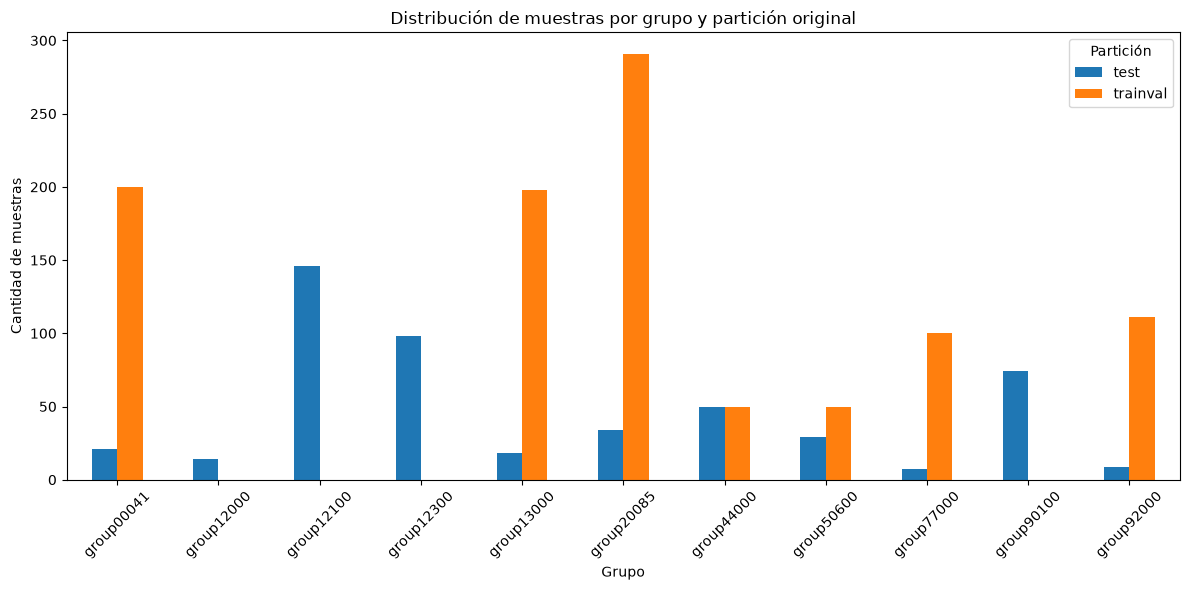

In [11]:
# Distribución de muestras por grupo y partición
group_plot_data = pd.crosstab(
    df_samples["group"],
    df_samples["original_split"]
)

ax = group_plot_data.plot(
    kind="bar",
    figsize=(12, 6)
)

ax.set_title("Distribución de muestras por grupo y partición original")
ax.set_xlabel("Grupo")
ax.set_ylabel("Cantidad de muestras")
ax.legend(title="Partición")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 5. Análisis de las anotaciones

Cada archivo de anotaciones de DeepPCB contiene una o más *bounding boxes* asociadas a los defectos presentes en la imagen correspondiente. El formato original de cada fila es:

`x_min y_min x_max y_max class_id`

En esta sección se consolidan todas las anotaciones en una única estructura tabular con el objetivo de analizar la cantidad de defectos, la distribución de clases y las características geométricas de las *bounding boxes*.

In [12]:
def load_annotations(df_samples: pd.DataFrame) -> pd.DataFrame:
    """
    Lee todos los archivos de anotaciones y consolida
    las bounding boxes en un único DataFrame.
    """
    records = []

    for _, sample in df_samples.iterrows():
        with open(sample["annotation_path"], "r", encoding="utf-8") as file:
            for line in file:
                line = line.strip()

                if not line:
                    continue

                x_min, y_min, x_max, y_max, class_id = map(
                    int,
                    line.split()
                )

                records.append({
                    "sample_id": sample["sample_id"],
                    "group": sample["group"],
                    "original_split": sample["original_split"],
                    "class_id": class_id,
                    "x_min": x_min,
                    "y_min": y_min,
                    "x_max": x_max,
                    "y_max": y_max,
                    "box_width": x_max - x_min,
                    "box_height": y_max - y_min,
                    "box_area": (x_max - x_min) * (y_max - y_min),
                })

    return pd.DataFrame(records)


df_annotations = load_annotations(df_samples)

print(f"Cantidad total de defectos anotados: {len(df_annotations)}")
print(f"Cantidad de imágenes: {len(df_samples)}")
print(
    f"Promedio de defectos por imagen: "
    f"{len(df_annotations) / len(df_samples):.2f}"
)

df_annotations.head()

Cantidad total de defectos anotados: 10013
Cantidad de imágenes: 1500
Promedio de defectos por imagen: 6.68


,sample_id,group,original_split,class_id,x_min,y_min,x_max,y_max,box_width,box_height,box_area
0,20085000,group20085,trainval,3,409,394,435,422,26,28,728
1,20085000,group20085,trainval,3,275,383,319,417,44,34,1496
2,20085000,group20085,trainval,4,8,163,36,191,28,28,784
3,20085000,group20085,trainval,5,244,151,270,182,26,31,806
4,20085000,group20085,trainval,6,338,519,364,543,26,24,624


In [13]:
print("Clases encontradas:")
print(sorted(df_annotations["class_id"].unique()))

print("\nCantidad de defectos por clase:")
print(
    df_annotations["class_id"]
    .value_counts()
    .sort_index()
)

Clases encontradas:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Cantidad de defectos por clase:
class_id
1    1942
2    1506
3    1965
4    1625
5    1474
6    1501
Name: count, dtype: int64


### 5.1 Distribución de defectos por clase

Se analiza la frecuencia de aparición de cada tipo de defecto en el conjunto completo de datos. La distribución de clases constituye un aspecto relevante para el entrenamiento de modelos de detección, dado que un desbalance pronunciado podría sesgar el aprendizaje hacia las categorías más frecuentes.

DeepPCB considera seis categorías de defectos: `open`, `short`, `mousebite`, `spur`, `copper` y `pin-hole`.

In [14]:
# Mapeo de identificadores originales a nombres de clase
CLASS_NAMES = {
    1: "open",
    2: "short",
    3: "mousebite",
    4: "spur",
    5: "copper",
    6: "pin-hole",
}

df_annotations["class_name"] = df_annotations["class_id"].map(
    CLASS_NAMES
)

# Verificar que todas las clases hayan sido mapeadas
assert df_annotations["class_name"].notna().all(), (
    "Se encontraron identificadores de clase sin nombre asociado."
)

class_distribution = (
    df_annotations["class_name"]
    .value_counts()
    .rename_axis("Clase")
    .reset_index(name="Cantidad de defectos")
)

class_distribution

,Clase,Cantidad de defectos
0,mousebite,1965
1,open,1942
2,spur,1625
3,short,1506
4,pin-hole,1501
5,copper,1474


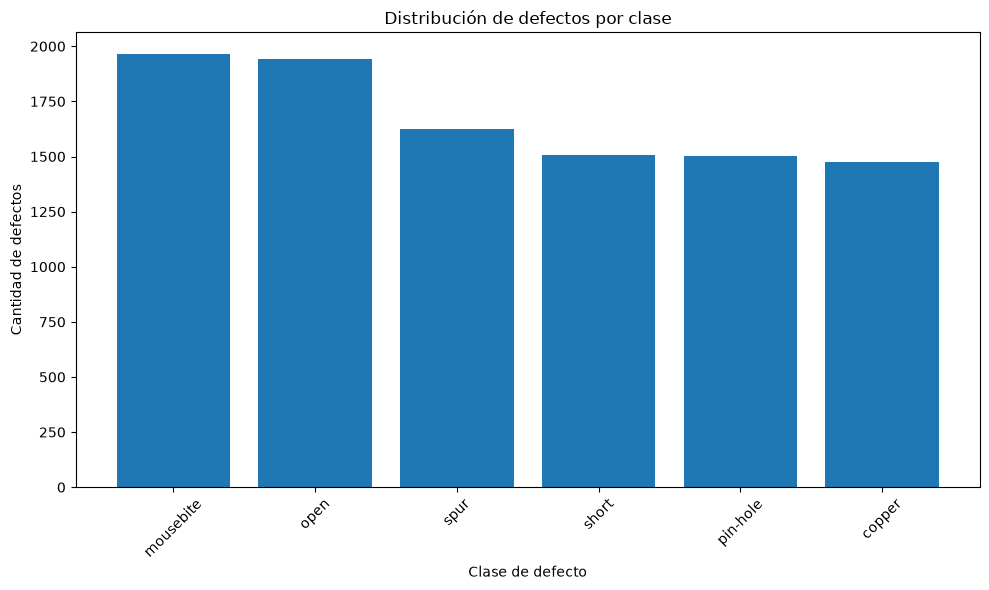

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    class_distribution["Clase"],
    class_distribution["Cantidad de defectos"]
)

ax.set_title("Distribución de defectos por clase")
ax.set_xlabel("Clase de defecto")
ax.set_ylabel("Cantidad de defectos")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

La distribución observada muestra una representación relativamente equilibrada de las seis categorías de defectos. Si bien existen diferencias en la frecuencia absoluta, ninguna clase presenta una participación extremadamente reducida respecto de las demás.

Las categorías `mousebite` y `open` son las más frecuentes, mientras que `copper`, `pin-hole` y `short` presentan menores cantidades de instancias. No obstante, el nivel de desbalance no parece suficientemente pronunciado como para justificar, en esta etapa, la aplicación de técnicas específicas de remuestreo o ponderación de clases.

Esta característica resulta favorable para el entrenamiento y la comparación de los modelos YOLO Nano y YOLO Small, dado que reduce el riesgo de que las métricas globales estén dominadas por una única categoría mayoritaria.

### 5.2 Distribución de clases por partición original

Además de analizar la distribución global de los defectos, se compara la frecuencia de cada clase entre las particiones `trainval` y `test`.

Este análisis permite identificar posibles diferencias en la composición de los conjuntos que puedan influir en la evaluación posterior de los modelos. Una representación muy desigual de determinadas clases entre entrenamiento y prueba podría afectar la interpretación de las métricas globales y por categoría.

In [16]:
# Cantidad de defectos por clase y partición original
class_split_distribution = pd.crosstab(
    df_annotations["class_name"],
    df_annotations["original_split"],
    margins=True
)

class_split_distribution

original_split,test,trainval,All
class_name,,,
copper,464,1010,1474
mousebite,586,1379,1965
open,659,1283,1942
pin-hole,470,1031,1501
short,478,1028,1506
spur,483,1142,1625
All,3140,6873,10013


In [17]:
# Distribución porcentual de clases dentro de cada partición
class_split_proportions = pd.crosstab(
    df_annotations["class_name"],
    df_annotations["original_split"],
    normalize="columns"
) * 100

class_split_proportions

original_split,test,trainval
class_name,,
copper,14.777070,14.695184
mousebite,18.662420,20.064019
open,20.987261,18.667249
pin-hole,14.968153,15.000727
short,15.222930,14.957078
spur,15.382166,16.615743


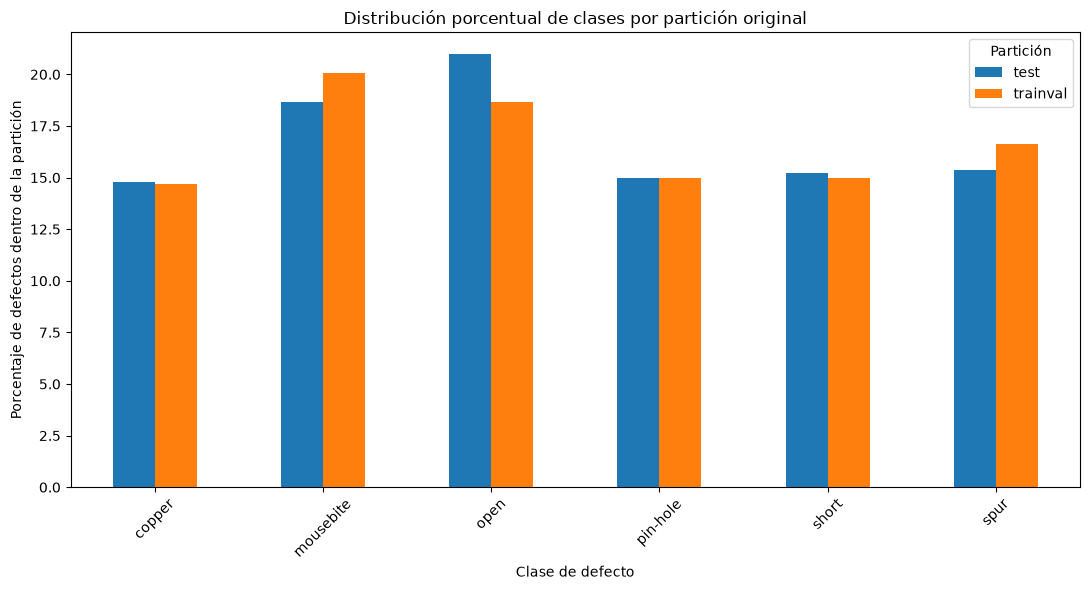

In [18]:
ax = class_split_proportions.plot(
    kind="bar",
    figsize=(11, 6)
)

ax.set_title("Distribución porcentual de clases por partición original")
ax.set_xlabel("Clase de defecto")
ax.set_ylabel("Porcentaje de defectos dentro de la partición")
ax.legend(title="Partición")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

#### Interpretación

La distribución relativa de las clases resulta similar entre las particiones `trainval` y `test`, sin observarse cambios pronunciados en la composición de los conjuntos.

Las principales diferencias se presentan en las categorías `open`, cuya participación aumenta de aproximadamente 18,7 % en `trainval` a 21,0 % en `test`, y `mousebite`, que disminuye de aproximadamente 20,1 % a 18,7 %. El resto de las categorías mantiene proporciones comparables entre ambas particiones.

En términos generales, no se identifica un desbalance significativo de clases entre los conjuntos. Este resultado es favorable para la evaluación posterior, dado que reduce el riesgo de que las diferencias de desempeño observadas entre los modelos estén explicadas principalmente por un cambio abrupto en la frecuencia relativa de las categorías.

No obstante, la similitud en la distribución de clases no garantiza por sí sola que ambas particiones presenten la misma dificultad. Factores como el tamaño de los defectos, su apariencia visual y la pertenencia a distintos grupos de PCB también podrían afectar la capacidad de generalización de los modelos, por lo que serán analizados posteriormente.

## 6. Cantidad de defectos por imagen

Se analiza la cantidad de defectos anotados en cada imagen con el objetivo de caracterizar la complejidad de las escenas presentes en el dataset.

La coexistencia de múltiples defectos en una misma PCB puede incrementar la dificultad de la tarea de detección, especialmente cuando las anomalías se encuentran próximas entre sí o corresponden a diferentes categorías.

In [19]:
# Cantidad de defectos por imagen
defects_per_image = (
    df_annotations
    .groupby("sample_id")
    .size()
    .rename("defect_count")
    .reset_index()
)

# Incorporar información de partición y grupo
defects_per_image = defects_per_image.merge(
    df_samples[
        ["sample_id", "group", "original_split"]
    ],
    on="sample_id",
    how="left"
)

defects_per_image["defect_count"].describe()

count    1500.000000
mean        6.675333
std         1.809634
min         1.000000
25%         5.000000
50%         7.000000
75%         8.000000
max        15.000000
Name: defect_count, dtype: float64

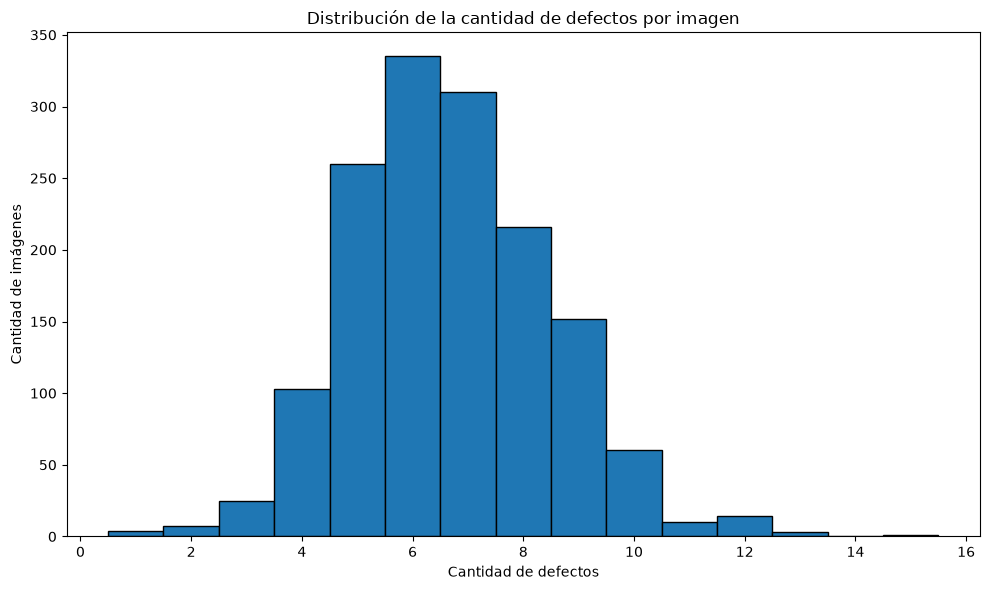

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    defects_per_image["defect_count"],
    bins=range(
        defects_per_image["defect_count"].min(),
        defects_per_image["defect_count"].max() + 2
    ),
    edgecolor="black",
    align="left"
)

ax.set_title("Distribución de la cantidad de defectos por imagen")
ax.set_xlabel("Cantidad de defectos")
ax.set_ylabel("Cantidad de imágenes")

plt.tight_layout()
plt.show()

In [21]:
defects_per_image.groupby(
    "original_split"
)["defect_count"].describe()

,count,mean,std,min,25%,50%,75%,max
original_split,,,,,,,,
test,500.0,6.280,1.456655,2.0,5.0,6.0,7.0,13.0
trainval,1000.0,6.873,1.933031,1.0,6.0,7.0,8.0,15.0


### 6.1 Interpretación

Las imágenes del dataset contienen, en promedio, aproximadamente 6,68 defectos anotados, con una mediana de 7 defectos por imagen. La cantidad observada varía entre 1 y 15 defectos, lo que evidencia la presencia de escenas con distintos niveles de complejidad.

Al comparar las particiones originales, `trainval` presenta una media de aproximadamente 6,87 defectos por imagen, mientras que `test` alcanza 6,28. Asimismo, la mediana es de 7 defectos en `trainval` y de 6 en `test`, y la dispersión resulta ligeramente mayor en el primer conjunto.

Por lo tanto, la partición de prueba no parece presentar una mayor complejidad en términos de cantidad de defectos simultáneos por imagen. En consecuencia, una eventual disminución del desempeño sobre `test` no podría atribuirse directamente a una mayor densidad de objetos, aunque otros factores como el tamaño de los defectos, su apariencia visual o la presencia de grupos de PCB no observados durante el entrenamiento podrían influir en la capacidad de generalización.

## 7. Análisis del tamaño de los defectos

Se analizan las dimensiones de las *bounding boxes* con el objetivo de caracterizar el tamaño de los defectos presentes en el dataset.

El tamaño de los objetos constituye un factor relevante en tareas de detección, dado que los defectos pequeños pueden resultar más difíciles de localizar y clasificar. Este análisis permitirá evaluar la distribución de anchos, altos y áreas de las anotaciones, así como identificar posibles diferencias entre clases.

In [22]:
# Obtener dimensiones de las imágenes
image_dimensions = []

for _, sample in df_samples.iterrows():
    image = cv2.imread(str(sample["image_path"]))

    if image is None:
        continue

    height, width = image.shape[:2]

    image_dimensions.append({
        "sample_id": sample["sample_id"],
        "image_width": width,
        "image_height": height,
    })

df_image_dimensions = pd.DataFrame(image_dimensions)

print("Dimensiones únicas encontradas:")
print(
    df_image_dimensions[
        ["image_width", "image_height"]
    ]
    .drop_duplicates()
    .sort_values(["image_width", "image_height"])
)

Dimensiones únicas encontradas:
   image_width  image_height
0          640           640


### 7.1 Dimensiones de las imágenes y tamaño relativo de los defectos

Todas las imágenes analizadas presentan una resolución uniforme de 640 × 640 píxeles. Esta homogeneidad simplifica la comparación de las *bounding boxes* y permite expresar el tamaño de cada defecto como proporción del área total de la imagen.

El análisis del tamaño relativo resulta relevante debido a que los objetos pequeños suelen representar un mayor desafío para los modelos de detección, al contener menos información visual y ocupar una proporción reducida de la imagen.

In [24]:
# Dimensiones uniformes del dataset
IMAGE_WIDTH = 640
IMAGE_HEIGHT = 640
IMAGE_AREA = IMAGE_WIDTH * IMAGE_HEIGHT

# Calcular dimensiones relativas de las bounding boxes
df_annotations["relative_width"] = (
    df_annotations["box_width"] / IMAGE_WIDTH
)

df_annotations["relative_height"] = (
    df_annotations["box_height"] / IMAGE_HEIGHT
)

df_annotations["relative_area"] = (
    df_annotations["box_area"] / IMAGE_AREA
)

# Resumen descriptivo
df_annotations[
    [
        "box_width",
        "box_height",
        "box_area",
        "relative_width",
        "relative_height",
        "relative_area",
    ]
].describe()

,box_width,box_height,box_area,relative_width,relative_height,relative_area
count,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000,10013.000000
mean,38.928593,35.672126,1425.640368,0.060826,0.055738,0.003481
std,13.392840,11.169385,878.076111,0.020926,0.017452,0.002144
min,18.000000,19.000000,400.000000,0.028125,0.029687,0.000977
25%,31.000000,29.000000,962.000000,0.048438,0.045312,0.002349
50%,35.000000,33.000000,1184.000000,0.054688,0.051562,0.002891
75%,42.000000,39.000000,1560.000000,0.065625,0.060937,0.003809
max,173.000000,152.000000,16750.000000,0.270313,0.237500,0.040894


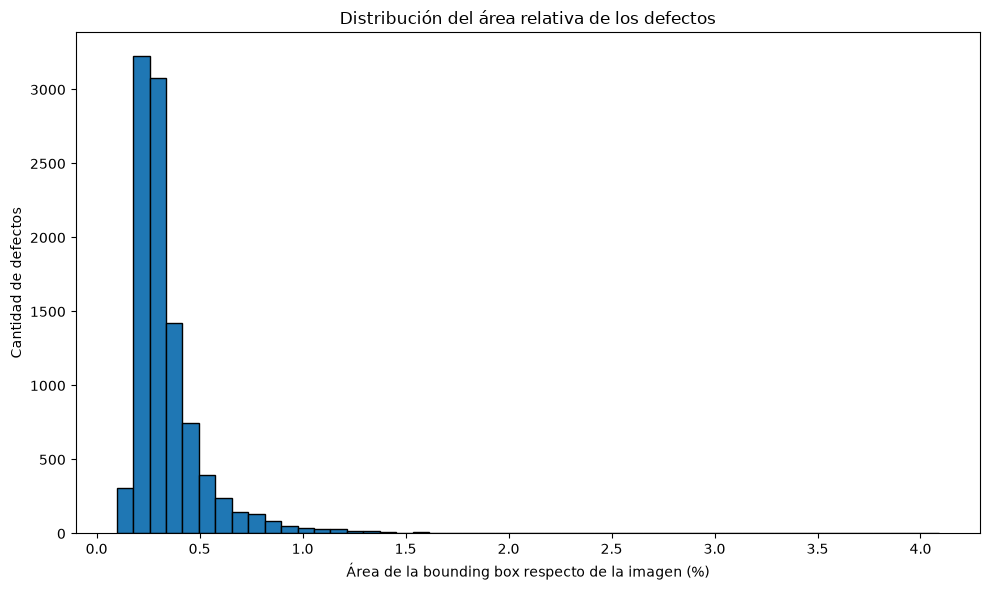

In [25]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df_annotations["relative_area"] * 100,
    bins=50,
    edgecolor="black"
)

ax.set_title("Distribución del área relativa de los defectos")
ax.set_xlabel("Área de la bounding box respecto de la imagen (%)")
ax.set_ylabel("Cantidad de defectos")

plt.tight_layout()
plt.show()

In [26]:
relative_area_by_class = (
    df_annotations
    .groupby("class_name")["relative_area"]
    .describe()
)

relative_area_by_class

,count,mean,std,min,25%,50%,75%,max
class_name,,,,,,,,
copper,1474.0,0.003543,0.001571,0.001289,0.002573,0.003154,0.004039,0.015601
mousebite,1965.0,0.002780,0.001169,0.000977,0.002109,0.002500,0.003103,0.020186
open,1942.0,0.004402,0.003286,0.001221,0.002578,0.003223,0.005054,0.040894
pin-hole,1501.0,0.002956,0.001449,0.001179,0.002175,0.002649,0.003418,0.035713
short,1506.0,0.004334,0.002495,0.001692,0.002900,0.003629,0.004687,0.036621
spur,1625.0,0.002863,0.000951,0.001333,0.002271,0.002637,0.003162,0.013330


### 7.2 Interpretación

El análisis evidencia que los defectos anotados ocupan una proporción reducida de la superficie total de las imágenes. La *bounding box* típica presenta dimensiones cercanas a 35 × 33 píxeles dentro de imágenes de 640 × 640 píxeles. En términos relativos, el área mediana de los defectos representa aproximadamente el 0,29 % del área total de la imagen, mientras que el 75 % de las anotaciones se encuentra por debajo de aproximadamente el 0,38 %.

Este resultado indica que la tarea de detección se encuentra caracterizada por objetos visualmente pequeños respecto del tamaño total de la escena. Esta condición puede incrementar la dificultad del problema, dado que los defectos contienen una cantidad limitada de información visual y pueden presentar patrones similares entre categorías.

Asimismo, se observan diferencias entre clases. Las categorías `open` y `short` presentan, en promedio, áreas relativas mayores, mientras que `mousebite`, `spur` y `pin-hole` tienden a ocupar regiones más reducidas. Estas diferencias permiten plantear como hipótesis que el desempeño de detección podría variar según el tamaño característico de cada clase.

En particular, durante la evaluación de YOLO Nano y YOLO Small se analizará si las categorías con defectos de menor tamaño presentan menores niveles de *recall* o mAP, y si la mayor capacidad representacional del modelo Small produce mejoras frente al modelo Nano. Esta relación será evaluada empíricamente a partir de los resultados obtenidos y no se asumirá de manera previa al entrenamiento.

### 7.3 Comparación del tamaño de los defectos entre clases

Se compara la distribución del área relativa de las *bounding boxes* entre categorías con el objetivo de identificar diferencias sistemáticas en el tamaño de los defectos.

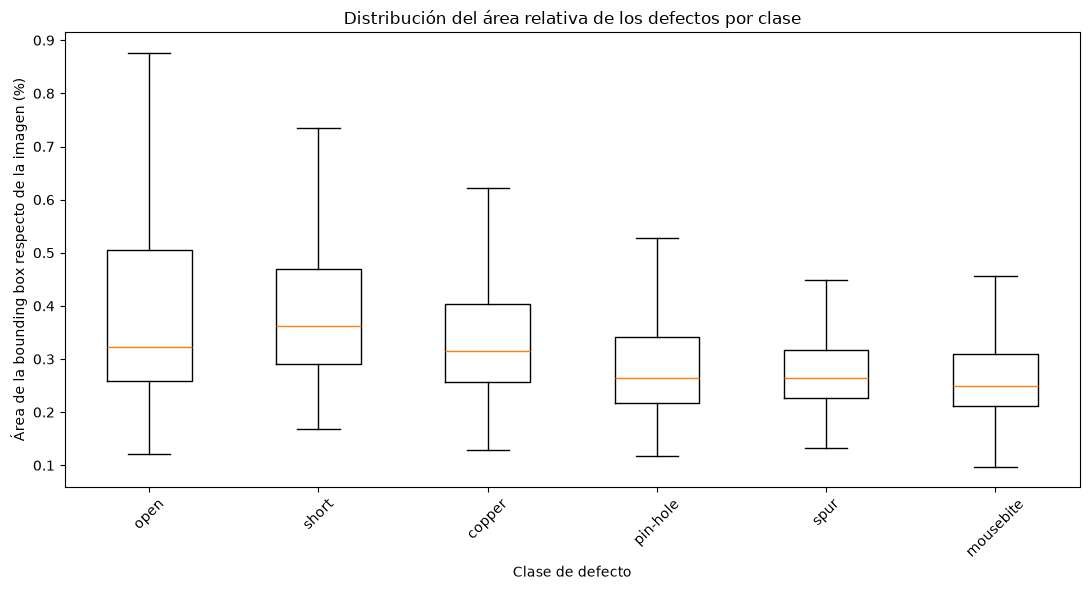

In [27]:
fig, ax = plt.subplots(figsize=(11, 6))

class_order = [
    "open",
    "short",
    "copper",
    "pin-hole",
    "spur",
    "mousebite",
]

boxplot_data = [
    df_annotations.loc[
        df_annotations["class_name"] == class_name,
        "relative_area"
    ] * 100
    for class_name in class_order
]

ax.boxplot(
    boxplot_data,
    tick_labels=class_order,
    showfliers=False
)

ax.set_title("Distribución del área relativa de los defectos por clase")
ax.set_xlabel("Clase de defecto")
ax.set_ylabel("Área de la bounding box respecto de la imagen (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 8. Visualización de imágenes anotadas

Se visualizan muestras del dataset junto con sus *bounding boxes* y etiquetas de clase originales.

Esta etapa permite validar visualmente la correspondencia entre imágenes y anotaciones, verificar la interpretación de las coordenadas y detectar posibles inconsistencias antes de realizar la conversión al formato requerido por YOLO.

In [28]:
def plot_annotated_sample(
    sample_id: str,
    df_samples: pd.DataFrame,
    df_annotations: pd.DataFrame,
    figsize: tuple = (8, 8)
) -> None:
    """
    Visualiza una imagen del dataset con sus bounding boxes
    y nombres de clase.
    """
    sample_rows = df_samples[
        df_samples["sample_id"] == sample_id
    ]

    if sample_rows.empty:
        raise ValueError(
            f"No se encontró la muestra {sample_id}."
        )

    sample = sample_rows.iloc[0]

    image = cv2.imread(str(sample["image_path"]))

    if image is None:
        raise ValueError(
            f"No se pudo leer la imagen {sample['image_path']}."
        )

    # OpenCV carga imágenes en BGR; Matplotlib espera RGB
    image_rgb = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    sample_annotations = df_annotations[
        df_annotations["sample_id"] == sample_id
    ]

    fig, ax = plt.subplots(figsize=figsize)

    ax.imshow(image_rgb)

    for _, annotation in sample_annotations.iterrows():
        x_min = annotation["x_min"]
        y_min = annotation["y_min"]
        width = annotation["box_width"]
        height = annotation["box_height"]
        class_name = annotation["class_name"]

        rectangle = plt.Rectangle(
            (x_min, y_min),
            width,
            height,
            fill=False,
            linewidth=2
        )

        ax.add_patch(rectangle)

        ax.text(
            x_min,
            max(y_min - 5, 0),
            class_name,
            fontsize=9,
            bbox={
                "facecolor": "white",
                "alpha": 0.7,
                "edgecolor": "none"
            }
        )

    ax.set_title(
        f"Muestra {sample_id} | "
        f"Partición: {sample['original_split']} | "
        f"Defectos: {len(sample_annotations)}"
    )

    ax.axis("off")

    plt.tight_layout()
    plt.show()

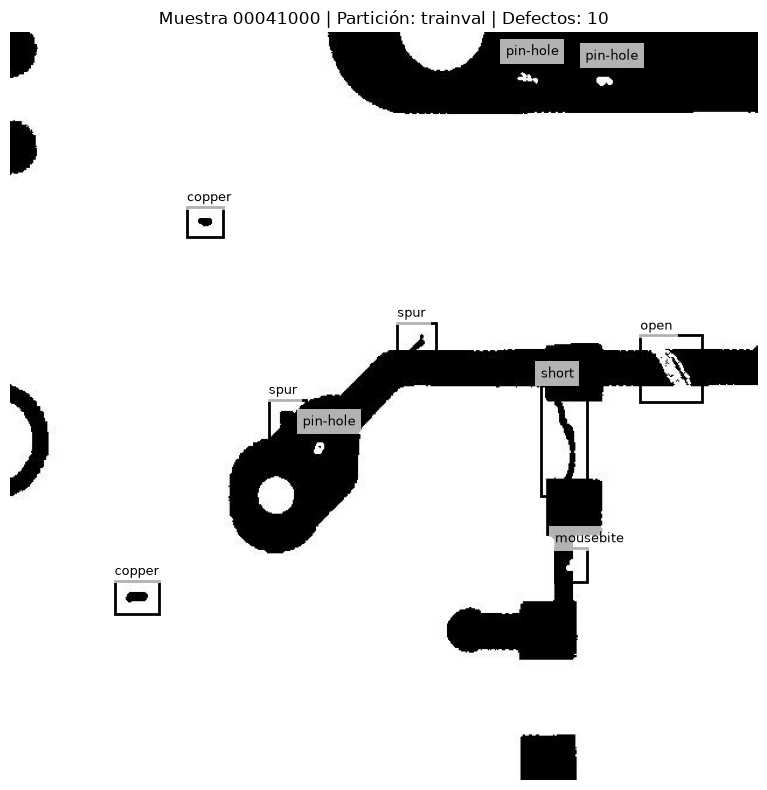

In [29]:
plot_annotated_sample(
    sample_id="00041000",
    df_samples=df_samples,
    df_annotations=df_annotations
)

### 8.1 Ejemplos representativos por clase

Se selecciona automáticamente una muestra que contenga cada una de las seis categorías de defectos. Esta visualización permite observar las diferencias morfológicas entre clases y evaluar cualitativamente la complejidad de la tarea de detección.

In [30]:
# Seleccionar una muestra representativa para cada clase
representative_samples = (
    df_annotations
    .groupby("class_name")["sample_id"]
    .first()
    .to_dict()
)

representative_samples

{'copper': '20085000',
 'mousebite': '20085000',
 'open': '20085003',
 'pin-hole': '20085000',
 'short': '20085003',
 'spur': '20085000'}

Clase objetivo: copper


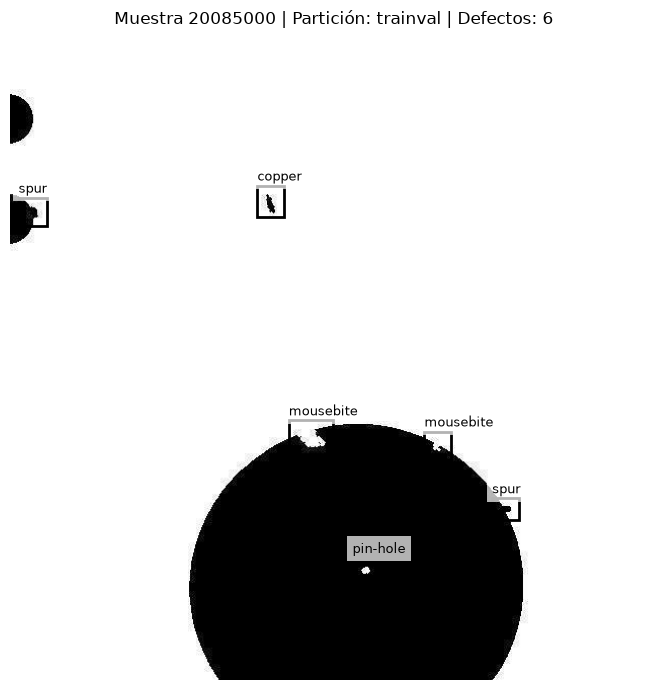

Clase objetivo: mousebite


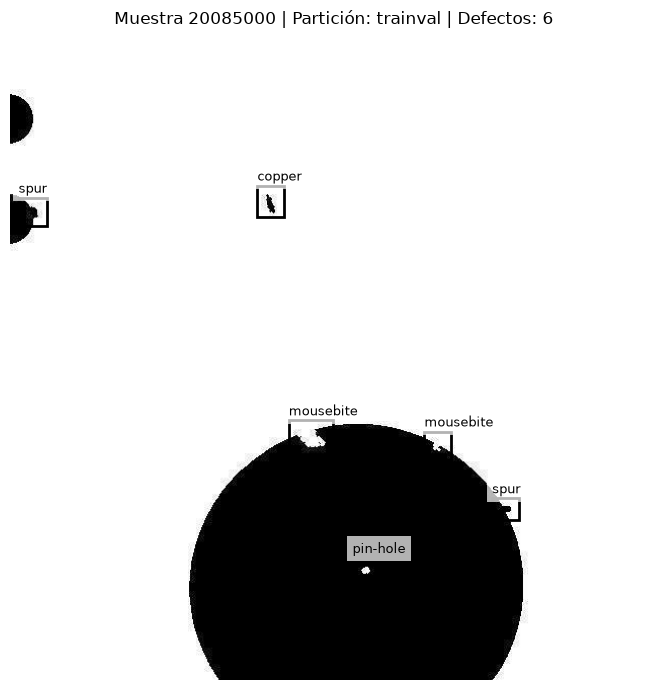

Clase objetivo: open


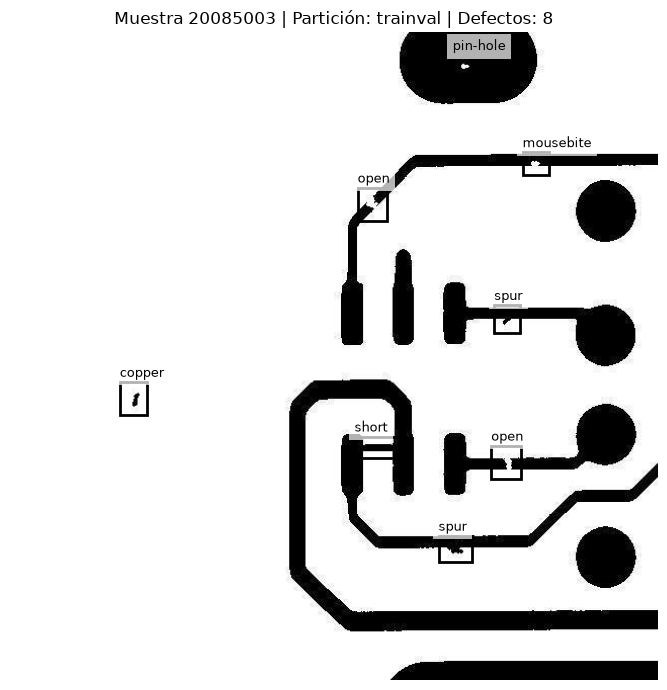

Clase objetivo: pin-hole


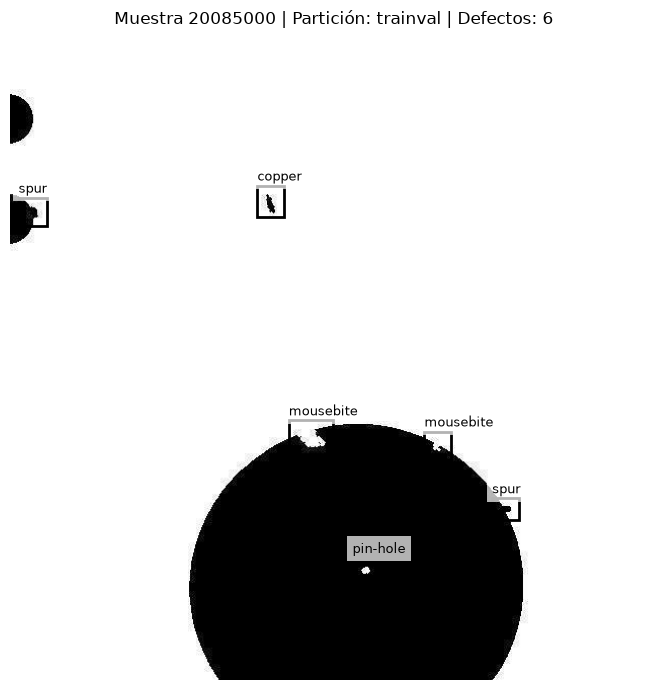

Clase objetivo: short


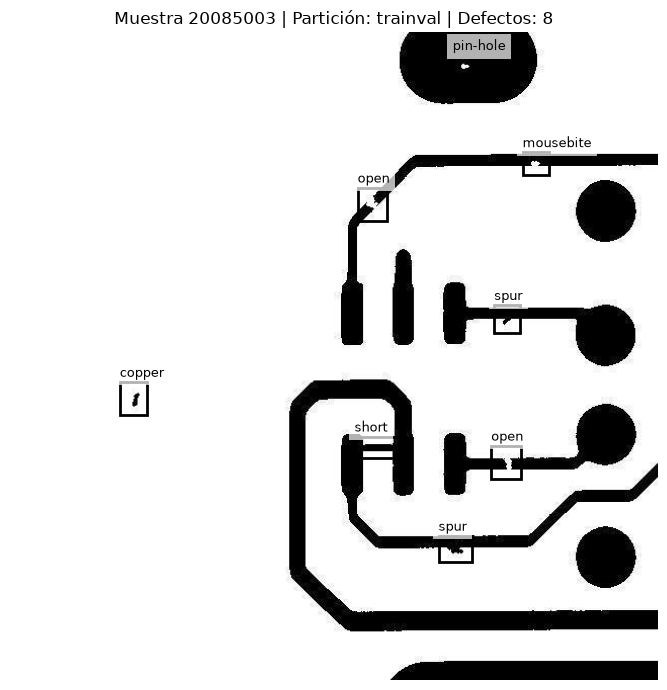

Clase objetivo: spur


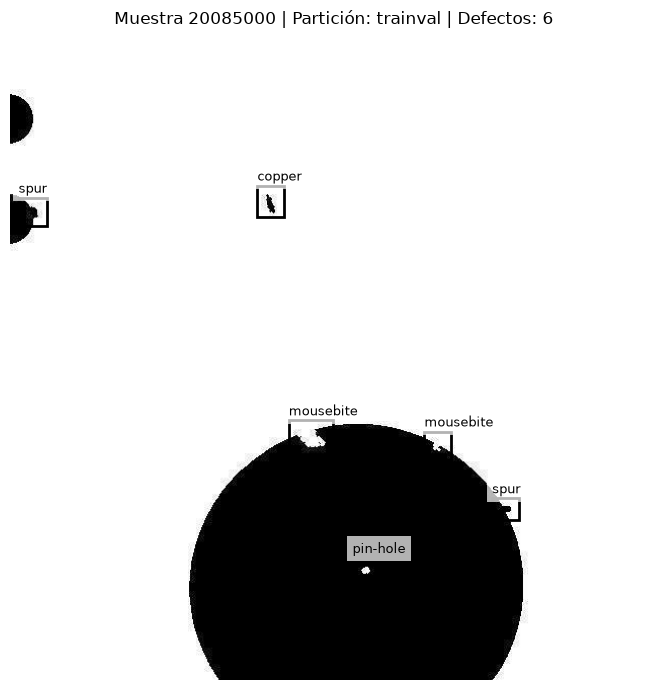

In [31]:
for class_name, sample_id in representative_samples.items():
    print(f"Clase objetivo: {class_name}")

    plot_annotated_sample(
        sample_id=sample_id,
        df_samples=df_samples,
        df_annotations=df_annotations,
        figsize=(7, 7)
    )

### 8.2 Interpretación cualitativa

La inspección visual confirma que las anotaciones se encuentran correctamente alineadas con las regiones defectuosas y que las imágenes pueden contener múltiples anomalías, incluyendo defectos pertenecientes a diferentes categorías dentro de una misma PCB.

Asimismo, se observa que los defectos ocupan regiones reducidas respecto del tamaño total de la imagen y presentan diferencias morfológicas sutiles entre algunas categorías. Esta característica refuerza la complejidad del problema de detección y resulta consistente con el análisis cuantitativo previo sobre el tamaño relativo de las *bounding boxes*.

La coexistencia de múltiples defectos por imagen y el reducido tamaño relativo de las anomalías constituyen aspectos relevantes para la posterior evaluación de los modelos YOLO Nano y YOLO Small.

## 9. Definición de las particiones de entrenamiento y validación

El dataset proporciona una partición original `trainval` de 1000 imágenes y una partición `test` de 500 imágenes. Para el entrenamiento de los modelos YOLO es necesario subdividir `trainval` en conjuntos de entrenamiento y validación, preservando `test` exclusivamente para la evaluación final.

Antes de realizar esta división, se analiza la distribución conjunta de grupos y clases dentro de `trainval`. El objetivo es evitar una partición que introduzca diferencias artificiales entre entrenamiento y validación o que genere una representación insuficiente de determinadas categorías.

In [32]:
# Filtrar únicamente las anotaciones de trainval
df_annotations_trainval = df_annotations[
    df_annotations["original_split"] == "trainval"
].copy()

# Distribución de defectos por grupo y clase
trainval_group_class = pd.crosstab(
    df_annotations_trainval["group"],
    df_annotations_trainval["class_name"]
)

trainval_group_class

class_name,copper,mousebite,open,pin-hole,short,spur
group,,,,,,
group00041,232,347,278,221,203,254
group13000,233,300,196,235,138,243
group20085,289,414,457,256,421,361
group44000,47,79,84,57,60,51
group50600,39,44,55,52,45,47
group77000,83,99,85,106,71,81
group92000,87,96,128,104,90,105


In [33]:
# Presencia de clases por grupo
trainval_group_class_presence = (
    trainval_group_class > 0
).astype(int)

trainval_group_class_presence

class_name,copper,mousebite,open,pin-hole,short,spur
group,,,,,,
group00041,1,1,1,1,1,1
group13000,1,1,1,1,1,1
group20085,1,1,1,1,1,1
group44000,1,1,1,1,1,1
group50600,1,1,1,1,1,1
group77000,1,1,1,1,1,1
group92000,1,1,1,1,1,1


### 9.1 Estrategia de partición

La partición original `trainval` contiene siete grupos de PCB y las seis categorías de defectos se encuentran representadas en todos ellos. Sin embargo, se observan diferencias importantes en la cantidad de muestras y anotaciones aportadas por cada grupo.

Por este motivo, no se adopta una separación basada en reservar grupos completos para validación, ya que podría generar conjuntos con diferencias estructurales pronunciadas y una representación poco equilibrada de las condiciones presentes en los datos.

Se propone subdividir `trainval` en entrenamiento y validación mediante una partición reproducible 80/20 estratificada por grupo. De esta manera, se busca preservar aproximadamente la representación relativa de cada grupo en ambos conjuntos.

La partición `test` original se mantiene sin modificaciones y se reserva exclusivamente para la evaluación final de los modelos.

In [34]:
from sklearn.model_selection import train_test_split

# Muestras pertenecientes a la partición original trainval
df_trainval_samples = df_samples[
    df_samples["original_split"] == "trainval"
].copy()

# Split reproducible 80/20 estratificado por grupo
df_train, df_val = train_test_split(
    df_trainval_samples,
    test_size=0.20,
    random_state=42,
    stratify=df_trainval_samples["group"]
)

# Mantener test original sin modificaciones
df_test_final = df_samples[
    df_samples["original_split"] == "test"
].copy()

print(f"Train: {len(df_train)} imágenes")
print(f"Validation: {len(df_val)} imágenes")
print(f"Test: {len(df_test_final)} imágenes")

Train: 800 imágenes
Validation: 200 imágenes
Test: 500 imágenes


In [35]:
# Comparar distribución porcentual de grupos
group_split_comparison = pd.DataFrame({
    "train_%": (
        df_train["group"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ),
    "val_%": (
        df_val["group"]
        .value_counts(normalize=True)
        .sort_index() * 100
    ),
})

group_split_comparison.round(2)

,train_%,val_%
group,,
group00041,20.00,20.0
group13000,19.75,20.0
group20085,29.12,29.0
group44000,5.00,5.0
group50600,5.00,5.0
group77000,10.00,10.0
group92000,11.12,11.0


In [36]:
# Verificar que ninguna muestra aparezca en más de una partición
train_ids = set(df_train["sample_id"])
val_ids = set(df_val["sample_id"])
test_ids = set(df_test_final["sample_id"])

print(
    "Solapamiento Train-Val:",
    len(train_ids & val_ids)
)

print(
    "Solapamiento Train-Test:",
    len(train_ids & test_ids)
)

print(
    "Solapamiento Val-Test:",
    len(val_ids & test_ids)
)

Solapamiento Train-Val: 0
Solapamiento Train-Test: 0
Solapamiento Val-Test: 0


### 9.2 Validación de la distribución por grupo

La partición estratificada preserva de manera prácticamente idéntica la composición relativa de los grupos entre entrenamiento y validación.

Las diferencias observadas son mínimas y se explican por el redondeo necesario al asignar cantidades enteras de imágenes. Por lo tanto, ambos conjuntos mantienen una representación comparable de los grupos presentes en la partición original `trainval`.

No obstante, dado que la estratificación se realizó a nivel de grupo y no de clase, se verifica adicionalmente la distribución de las seis categorías de defectos en ambos conjuntos.

In [37]:
# Crear mapeo de muestra a nueva partición
split_mapping = {}

split_mapping.update({
    sample_id: "train"
    for sample_id in df_train["sample_id"]
})

split_mapping.update({
    sample_id: "val"
    for sample_id in df_val["sample_id"]
})

split_mapping.update({
    sample_id: "test"
    for sample_id in df_test_final["sample_id"]
})

# Asignar nueva partición a cada anotación
df_annotations["final_split"] = (
    df_annotations["sample_id"]
    .map(split_mapping)
)

# Validar que todas las anotaciones tengan partición asignada
assert df_annotations["final_split"].notna().all(), (
    "Existen anotaciones sin partición final asignada."
)

df_annotations["final_split"].value_counts()

final_split
train    5513
test     3140
val      1360
Name: count, dtype: int64

In [38]:
# Distribución porcentual de clases por partición final
final_class_proportions = pd.crosstab(
    df_annotations["class_name"],
    df_annotations["final_split"],
    normalize="columns"
) * 100

final_class_proportions.round(2)

final_split,test,train,val
class_name,,,
copper,14.78,14.96,13.60
mousebite,18.66,19.92,20.66
open,20.99,18.52,19.26
pin-hole,14.97,15.16,14.34
short,15.22,14.95,15.00
spur,15.38,16.49,17.13


In [39]:
# Cantidad absoluta de defectos por clase y partición final
final_class_counts = pd.crosstab(
    df_annotations["class_name"],
    df_annotations["final_split"]
)

final_class_counts

final_split,test,train,val
class_name,,,
copper,464,825,185
mousebite,586,1098,281
open,659,1021,262
pin-hole,470,836,195
short,478,824,204
spur,483,909,233


### 9.3 Validación de la distribución de clases

La comparación entre las particiones finales muestra que la distribución relativa de las seis categorías de defectos se preserva razonablemente entre entrenamiento y validación.

Las diferencias observadas son reducidas. La mayor variación corresponde a la categoría `copper`, que representa aproximadamente el 15,0 % de las anotaciones de entrenamiento y el 13,6 % de las anotaciones de validación. Para el resto de las clases, las diferencias se mantienen en niveles acotados.

Asimismo, todas las categorías cuentan con una cantidad significativa de instancias en el conjunto de validación, con valores comprendidos entre 185 y 281 defectos. Por lo tanto, no se considera necesario aplicar una estrategia de partición más compleja.

La estrategia final adoptada consiste en:

- **Train:** 800 imágenes obtenidas a partir de `trainval`.
- **Validation:** 200 imágenes obtenidas a partir de `trainval`.
- **Test:** 500 imágenes correspondientes a la partición original propuesta por los autores de DeepPCB.

La subdivisión entre entrenamiento y validación se realizó de manera reproducible, utilizando una semilla aleatoria fija (`random_state=42`) y estratificación por grupo. La partición `test` se mantuvo sin modificaciones y se reservará exclusivamente para la evaluación final de los modelos.

Esta estrategia permite comparar YOLO Nano y YOLO Small bajo particiones idénticas, preservando de manera aproximada tanto la composición por grupo como la distribución de clases.

## 10. Conclusiones del análisis exploratorio

El análisis exploratorio permitió caracterizar la estructura, composición y principales desafíos del dataset DeepPCB antes de iniciar el entrenamiento de los modelos.

Los principales hallazgos son:

- El dataset contiene **1500 imágenes** con sus correspondientes archivos de anotaciones, sin registros faltantes.
- La partición original se compone de **1000 imágenes en `trainval`** y **500 imágenes en `test`**.
- Se identificaron **10.013 defectos anotados**, distribuidos entre seis categorías: `open`, `short`, `mousebite`, `spur`, `copper` y `pin-hole`.
- La distribución global de clases resulta relativamente equilibrada, sin observarse una categoría fuertemente dominante o minoritaria.
- La composición relativa de las clases es similar entre las particiones originales `trainval` y `test`.
- Las imágenes contienen, en promedio, aproximadamente **6,68 defectos**, evidenciando la presencia frecuente de múltiples anomalías dentro de una misma PCB.
- Todas las imágenes presentan una resolución uniforme de **640 × 640 píxeles**.
- Los defectos ocupan regiones pequeñas respecto del área total de la imagen. La *bounding box* mediana representa aproximadamente **0,29 %** de la superficie de la imagen.
- Se identificaron diferencias en el tamaño característico de los defectos entre clases, lo que permitirá analizar posteriormente una posible relación entre tamaño y desempeño de detección.
- La inspección visual confirmó la correcta alineación de las *bounding boxes* con las regiones defectuosas.
- La partición final quedó definida en **800 imágenes de entrenamiento, 200 de validación y 500 de prueba**.
- La separación entre entrenamiento y validación preserva de manera aproximada la distribución de grupos y clases, mientras que la partición original de prueba se mantiene sin modificaciones.

Estos resultados permiten avanzar hacia la preparación del dataset para YOLO sobre una base validada y reproducible. La siguiente etapa consistirá en convertir las anotaciones originales al formato requerido por YOLO y generar la estructura de directorios correspondiente a las particiones `train`, `val` y `test`.